<a href="https://colab.research.google.com/github/vedant1008-DE/Machine-Learning-Essentials-Lab-Sem-6/blob/main/Assignment_8_Support_Vector_Machines_(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Question 1 — Load Datasets

In [ ]:
# Load datasets
iris = load_iris()
wine = load_wine()

# Convert to DataFrame
iris_X = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_y = iris.target

wine_X = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_y = wine.target

# Print details
print("IRIS DATASET")
print("Records:", iris_X.shape[0])
print("Classes:", len(np.unique(iris_y)))
print("Features:", iris.feature_names)

print("\nWINE DATASET")
print("Records:", wine_X.shape[0])
print("Classes:", len(np.unique(wine_y)))
print("Features:", wine.feature_names)

IRIS DATASET
Records: 150
Classes: 3
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

WINE DATASET
Records: 178
Classes: 3
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


Question 2 — Train-Test Split

In [ ]:
iris_X_train, iris_X_test, iris_y_train, iris_y_test = train_test_split(
    iris_X, iris_y, test_size=0.2, random_state=42)

wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine_X, wine_y, test_size=0.2, random_state=42)

print("Split done successfully")

Split done successfully


Question 3 — SVM (Linear Kernel)

In [ ]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(iris_X_train, iris_y_train)

y_pred_linear = svm_linear.predict(iris_X_test)

print("Accuracy (Linear SVM):", accuracy_score(iris_y_test, y_pred_linear))
print("Support Vectors:", svm_linear.n_support_)

Accuracy (Linear SVM): 1.0
Support Vectors: [ 3 11 11]


Question 4 — SVM (RBF Kernel)

In [ ]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(iris_X_train, iris_y_train)

y_pred_rbf = svm_rbf.predict(iris_X_test)

print("Accuracy (RBF SVM):", accuracy_score(iris_y_test, y_pred_rbf))

Accuracy (RBF SVM): 1.0


Question 5 — Decision Boundary Visualization (Iris)

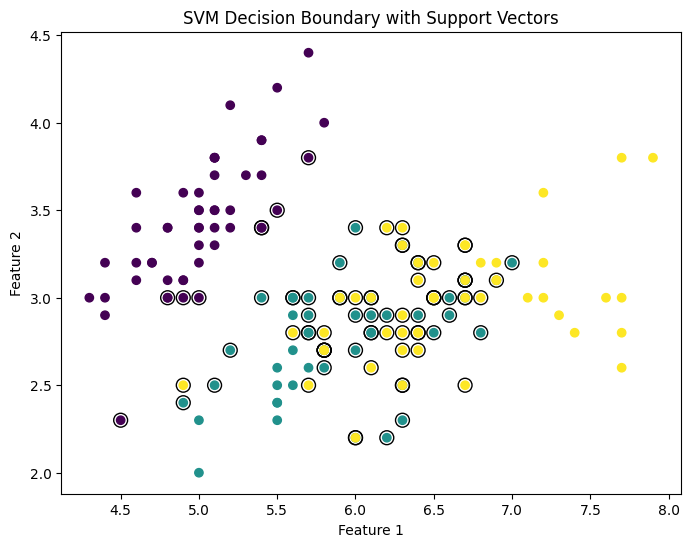

In [ ]:
# Select 2 features
X = iris_X.iloc[:, :2].values
y = iris_y

# Train SVM
model = SVC(kernel='linear')
model.fit(X, y)

# Plot
plt.figure(figsize=(8,6))

# Plot points
plt.scatter(X[:,0], X[:,1], c=y)

# Plot support vectors
plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary with Support Vectors")
plt.show()

Question 6 — Confusion Matrix & F1-score

In [ ]:
cm = confusion_matrix(iris_y_test, y_pred_rbf)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(iris_y_test, y_pred_rbf))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Question 7 — Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(iris_X_train, iris_y_train)

y_pred_log = log_model.predict(iris_X_test)

print("Logistic Accuracy:", accuracy_score(iris_y_test, y_pred_log))

Logistic Accuracy: 1.0


Question 8 — k-NN Comparison

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(iris_X_train, iris_y_train)

y_pred_knn = knn.predict(iris_X_test)

print("k-NN Accuracy:", accuracy_score(iris_y_test, y_pred_knn))

k-NN Accuracy: 1.0


Question 9 — Model Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM Linear", "SVM RBF", "k-NN"],
    "Accuracy": [
        accuracy_score(iris_y_test, y_pred_log),
        accuracy_score(iris_y_test, y_pred_linear),
        accuracy_score(iris_y_test, y_pred_rbf),
        accuracy_score(iris_y_test, y_pred_knn)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,SVM Linear,1.0
2,SVM RBF,1.0
3,k-NN,1.0


Question 10 — Reflection

In [ ]:
print("Reflection:\n")

print("When to use SVM:")
print("- When data is high dimensional")
print("- When margin separation is important\n")

print("When NOT to use SVM:")
print("- Large datasets (slow training)")
print("- Noisy data\n")

print("Why kernels matter:")
print("- Kernels allow SVM to handle non-linear data")

Reflection:

When to use SVM:
- When data is high dimensional
- When margin separation is important

When NOT to use SVM:
- Large datasets (slow training)
- Noisy data

Why kernels matter:
- Kernels allow SVM to handle non-linear data


Final Conclusion

In [ ]:
print("Conclusion:\n")

print("- SVM finds optimal margin between classes")
print("- Linear kernel works for simple data")
print("- RBF handles complex patterns")
print("- SVM often outperforms Logistic and k-NN")

Conclusion:

- SVM finds optimal margin between classes
- Linear kernel works for simple data
- RBF handles complex patterns
- SVM often outperforms Logistic and k-NN
